In [33]:
import numpy as np
import os
from scipy.spatial.distance import pdist, squareform

def read_mesh_file(filepath):
    """Read a .mesh file and extract vertices and edges."""
    vertices = None
    edges = None
    
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        
        # Read Vertices section
        if line.startswith('Vertices'):
            num_vertices = int(lines[i+1].strip())
            vertices = np.zeros((num_vertices, 2))
            i += 2
            for j in range(num_vertices):
                vertex_line = lines[i+j].strip()
                parts = [float(x) for x in vertex_line.split()]
                vertices[j] = [parts[0], parts[1]]  # Only x, y coordinates
            i += num_vertices
        
        # Read Edges section
        elif line.startswith('Edges'):
            num_edges = int(lines[i+1].strip())
            edges = np.zeros((num_edges, 2), dtype=int)
            i += 2
            for j in range(num_edges):
                edge_line = lines[i+j].strip()
                parts = [int(x) for x in edge_line.split()]
                edges[j] = [parts[0], parts[1]]  # Only first two vertices
            i += num_edges
        
        # Stop at Triangles section
        elif line.startswith('Triangles'):
            break
        else:
            i += 1
    
    return vertices, edges

def compute_winding_order(vertices):
    """
    Compute the winding order of polygon vertices using the shoelace formula.
    Returns: signed area (positive = counter-clockwise, negative = clockwise)
    """
    signed_area = 0.0
    n = len(vertices)
    for i in range(n):
        v1 = vertices[i]
        v2 = vertices[(i + 1) % n]
        signed_area += (v2[0] - v1[0]) * (v2[1] + v1[1])
    return signed_area / 2.0

def ensure_clockwise_order(vertices, edges):
    """
    Sort vertices in clockwise order by angle from centroid.
    Returns: vertices and edges reordered in clockwise order
    """
    # Find centroid
    centroid = np.mean(vertices, axis=0)
    
    # Compute angles from centroid to each vertex
    angles = np.arctan2(vertices[:, 1] - centroid[1], vertices[:, 0] - centroid[0])
    
    # Sort by angle in descending order for clockwise ordering
    # (clockwise means decreasing angle when viewed from above)
    sorted_indices = np.argsort(-angles)  # Negative for descending (clockwise)
    
    # Reorder vertices
    vertices_new = vertices[sorted_indices]
    
    # Rebuild edges directly from clockwise order
    # This guarantees connectivity follows vertex order: 1->2->...->N->1
    n_vertices = len(vertices_new)
    edges_new = np.zeros((n_vertices, 2), dtype=int)
    for i in range(n_vertices):
        edges_new[i] = [i + 1, ((i + 1) % n_vertices) + 1]
    
    return vertices_new, edges_new

def scale_shape_to_size(vertices, target_size):
    """
    Scale a shape so that the maximum distance between any two vertices equals target_size.
    
    Parameters:
    - vertices: Nx2 array of vertex coordinates
    - target_size: Target maximum pairwise distance (diameter)
    
    Returns:
    - Scaled vertices
    """
    if len(vertices) < 2:
        return vertices
    
    # Calculate pairwise distances
    pairwise_distances = squareform(pdist(vertices))
    max_distance = np.max(pairwise_distances)
    
    if max_distance > 0:
        scale_factor = target_size / max_distance
        vertices = vertices * scale_factor
    
    return vertices

def extract_boundary_vertices(vertices, edges):
    """
    Extract only boundary vertices (those used in edges).
    
    Parameters:
    - vertices: Nx2 array of all vertex coordinates
    - edges: Mx2 array of edge connectivity (1-based indices)
    
    Returns:
    - boundary_vertices: Kx2 array of boundary vertices only
    - remapped_edges: Mx2 array of edges with indices remapped to boundary vertices
    """
    # Find unique vertex indices used in edges (convert from 1-based to 0-based)
    boundary_indices_set = set()
    for edge in edges:
        boundary_indices_set.add(int(edge[0]) - 1)
        boundary_indices_set.add(int(edge[1]) - 1)
    
    # Sort boundary indices to maintain consistent ordering
    boundary_indices = sorted(list(boundary_indices_set))
    
    # Create mapping from old indices (1-based) to new indices (1-based)
    index_map = {}
    for new_idx, old_idx in enumerate(boundary_indices):
        index_map[old_idx + 1] = new_idx + 1  # Map from 1-based to 1-based
    
    # Extract boundary vertices
    boundary_vertices = vertices[boundary_indices]
    
    # Remap edges to new vertex indices
    remapped_edges = np.zeros_like(edges)
    for i, edge in enumerate(edges):
        old_v1 = int(edge[0])
        old_v2 = int(edge[1])
        remapped_edges[i] = [index_map[old_v1], index_map[old_v2]]
    
    return boundary_vertices, remapped_edges

def convert_mesh_to_sparta(vertices, edges, output_filepath, shape_name=None, ensure_clockwise=True, target_size=None):
    """Convert mesh vertices and edges to SPARTA format and save."""
    if vertices is None or edges is None:
        print(f"Warning: Invalid mesh data for {output_filepath}")
        return False
    
    # Extract only boundary vertices
    vertices, edges = extract_boundary_vertices(vertices, edges)
    
    # Enforce clockwise ordering if requested
    if ensure_clockwise:
        vertices, edges = ensure_clockwise_order(vertices, edges)
    
    # Scale shape if target size is specified
    if target_size is not None:
        vertices = scale_shape_to_size(vertices, target_size)
    
    num_points = len(vertices)
    num_lines = len(edges)
    
    if shape_name is None:
        shape_name = os.path.splitext(os.path.basename(output_filepath))[0]
    
    with open(output_filepath, 'w') as f:
        # Write header
        f.write(f"{shape_name}\n\n")
        f.write(f"{num_points} points\n")
        f.write(f"{num_lines} lines\n\n")
        
        # Write Points section
        f.write("Points\n\n")
        for point_idx, vertex in enumerate(vertices, start=1):
            f.write(f"{point_idx} {vertex[0]:.15e} {vertex[1]:.15e}\n")
        
        # Write Lines section
        f.write("\nLines\n\n")
        for line_idx, edge in enumerate(edges, start=1):
            # Mesh edges use 1-based indexing already, so use them directly
            f.write(f"{line_idx} {int(edge[0])} {int(edge[1])}\n")
    
    return True

def process_mesh_folder(mesh_folder_path, output_folder_path=None, ensure_clockwise=True, target_size=None):
    """
    Read all .mesh files from a folder and convert them to SPARTA format.
    
    Parameters:
    - mesh_folder_path: Path to folder containing meshes subfolder
    - output_folder_path: Path to save converted files (default: mesh_folder/sparta_converted)
    - ensure_clockwise: Whether to verify and enforce clockwise vertex ordering (default: True)
    - target_size: Target maximum pairwise distance for scaling (default: None, no scaling)
    """
    # Construct path to meshes subfolder
    meshes_path = os.path.join(mesh_folder_path, 'meshes')
    
    if not os.path.exists(meshes_path):
        print(f"Error: meshes folder not found at {meshes_path}")
        return
    
    # Create output folder
    if output_folder_path is None:
        output_folder_path = os.path.join(mesh_folder_path, 'sparta_converted')
    
    if not os.path.exists(output_folder_path):
        os.makedirs(output_folder_path)
        print(f"Created output folder: {output_folder_path}")
    
    # Process all .mesh files
    mesh_files = [f for f in os.listdir(meshes_path) if f.endswith('.mesh')]
    mesh_files.sort()
    
    print(f"Found {len(mesh_files)} mesh files to process")
    print(f"Clockwise enforcement: {'ON' if ensure_clockwise else 'OFF'}")
    print(f"Target size scaling: {target_size if target_size is not None else 'OFF'}\n")
    
    for mesh_idx, mesh_file in enumerate(mesh_files):
        mesh_filepath = os.path.join(meshes_path, mesh_file)
        
        # Read mesh file
        vertices, edges = read_mesh_file(mesh_filepath)
        
        if vertices is None or edges is None:
            print(f"  Skipped {mesh_file}: Could not parse vertices/edges")
            continue
        
        # Generate output filename
        base_name = os.path.splitext(mesh_file)[0]
        output_filepath = os.path.join(output_folder_path, f"{base_name}.txt")
        
        # Convert and save
        success = convert_mesh_to_sparta(vertices, edges, output_filepath, 
                                        shape_name=base_name, ensure_clockwise=ensure_clockwise, 
                                        target_size=target_size)
        
        if success:
            if (mesh_idx + 1) % 10 == 0 or mesh_idx == len(mesh_files) - 1:
                print(f"  [{mesh_idx + 1}/{len(mesh_files)}] Processed {base_name}.txt")
        else:
            print(f"  Failed to convert {mesh_file}")
    
    print(f"\n✓ Conversion complete!")
    print(f"  Total files: {len(mesh_files)}")
    print(f"  Output folder: {output_folder_path}")

##### STEP 1 #######
# Example usage:
# Specify the root folder containing the meshes subfolder
mesh_root_folder = "shapes/dataset_2026-02-06_09_28_35"
process_mesh_folder(mesh_root_folder, target_size=0.3)
#####################

Found 100 mesh files to process
Clockwise enforcement: ON
Target size scaling: 0.3

  [10/100] Processed shape_17.txt
  [20/100] Processed shape_26.txt
  [30/100] Processed shape_35.txt
  [40/100] Processed shape_44.txt
  [50/100] Processed shape_53.txt
  [60/100] Processed shape_62.txt
  [70/100] Processed shape_71.txt
  [80/100] Processed shape_80.txt
  [90/100] Processed shape_9.txt
  [100/100] Processed shape_99.txt

✓ Conversion complete!
  Total files: 100
  Output folder: shapes/dataset_2026-02-06_09_28_35/sparta_converted


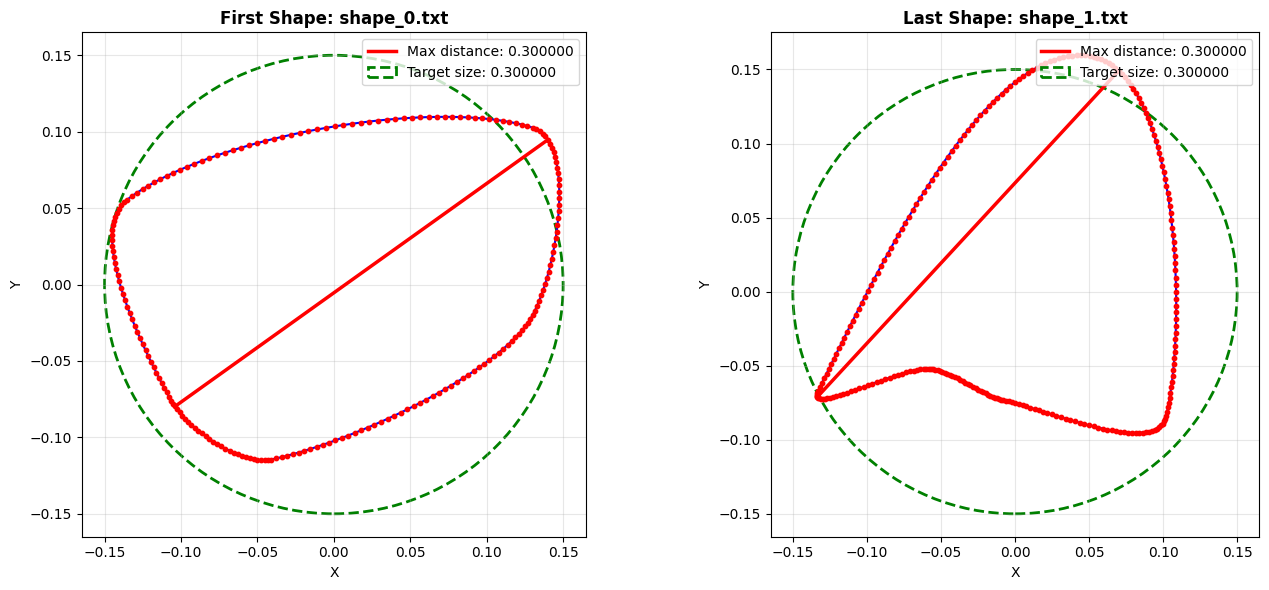


First shape: shape_0.txt (204 vertices, 204 edges)
Last shape: shape_1.txt (253 vertices, 253 edges)
Target size (max pairwise distance): 0.300000


In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def read_sparta_file(filepath):
    """Read a SPARTA format file and extract points and lines."""
    points = {}
    lines = []
    
    with open(filepath, 'r') as f:
        lines_raw = f.readlines()
    
    in_points = False
    in_lines = False
    
    for line in lines_raw:
        line = line.strip()
        if not line:
            continue
        
        if line == "Points":
            in_points = True
            in_lines = False
            continue
        elif line == "Lines":
            in_points = False
            in_lines = True
            continue
        
        if in_points:
            parts = line.split()
            if len(parts) >= 3:
                idx = int(parts[0])
                x = float(parts[1])
                y = float(parts[2])
                points[idx] = [x, y]
        elif in_lines:
            parts = line.split()
            if len(parts) >= 3:
                line_idx = int(parts[0])
                p1 = int(parts[1])
                p2 = int(parts[2])
                if p1 in points and p2 in points:
                    lines.append((points[p1], points[p2]))
    
    return points, lines

def plot_shape(points, lines, title="Shape", ax=None, target_size=None):
    """Plot a shape from SPARTA format with optional target size circle and max distance line."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plot edges
    for p1, p2 in lines:
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'b-', linewidth=1.5)
    
    # Plot vertices
    if points:
        vertices = list(points.values())
        vertices_array = np.array(vertices)
        ax.scatter(vertices_array[:, 0], vertices_array[:, 1], color='red', s=10, zorder=5)
        
        # Find and plot the line between the two points with maximum distance
        if len(vertices_array) >= 2:
            pairwise_distances = squareform(pdist(vertices_array))
            max_dist_idx = np.unravel_index(np.argmax(pairwise_distances), pairwise_distances.shape)
            p1_max = vertices_array[max_dist_idx[0]]
            p2_max = vertices_array[max_dist_idx[1]]
            max_distance = pairwise_distances[max_dist_idx]
            
            # Draw line between max distance points
            ax.plot([p1_max[0], p2_max[0]], [p1_max[1], p2_max[1]], 'r-', linewidth=2.5, 
                   label=f'Max distance: {max_distance:.6f}', zorder=4)
    
    # Plot target size circle if provided
    if target_size is not None:
        # Find centroid for circle center
        if points:
            vertices = np.array(list(points.values()))
            centroid = np.mean(vertices, axis=0)
            # Draw circle with diameter = target_size
            radius = target_size / 2.0
            circle = plt.Circle(centroid, radius, fill=False, color='green', 
                              linestyle='--', linewidth=2, label=f'Target size: {target_size:.6f}')
            ax.add_patch(circle)
    
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(loc='upper right')
    
    return ax

# Plot first and last shapes
def plot_mesh_shapes(sparta_folder, target_size=None):
    """Plot the first and last shapes from the SPARTA folder for debugging."""
    # Get all SPARTA files
    sparta_files = sorted([f for f in os.listdir(sparta_folder) if f.endswith('.txt')])
    
    if not sparta_files:
        print(f"No SPARTA files found in {sparta_folder}")
        return
    
    first_file = sparta_files[0]
    last_file = sparta_files[1]
    
    # Read files
    first_path = os.path.join(sparta_folder, first_file)
    last_path = os.path.join(sparta_folder, last_file)
    
    points_first, lines_first = read_sparta_file(first_path)
    points_last, lines_last = read_sparta_file(last_path)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    plot_shape(points_first, lines_first, f"First Shape: {first_file}", ax=ax1, target_size=target_size)
    plot_shape(points_last, lines_last, f"Last Shape: {last_file}", ax=ax2, target_size=target_size)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nFirst shape: {first_file} ({len(points_first)} vertices, {len(lines_first)} edges)")
    print(f"Last shape: {last_file} ({len(points_last)} vertices, {len(lines_last)} edges)")
    if target_size is not None:
        print(f"Target size (max pairwise distance): {target_size:.6f}")


##### STEP 2 #######
# Example usage - plot shapes from the SPARTA converted folder
sparta_folder = "shapes/dataset_2026-02-06_09_28_35/sparta_converted"
target_size = 0.3  # Match the target_size used in conversion
if os.path.exists(sparta_folder):
    plot_mesh_shapes(sparta_folder, target_size=target_size)
else:
    print(f"SPARTA folder not found at: {sparta_folder}")
######################

=== Visualization: Circle Unions ===


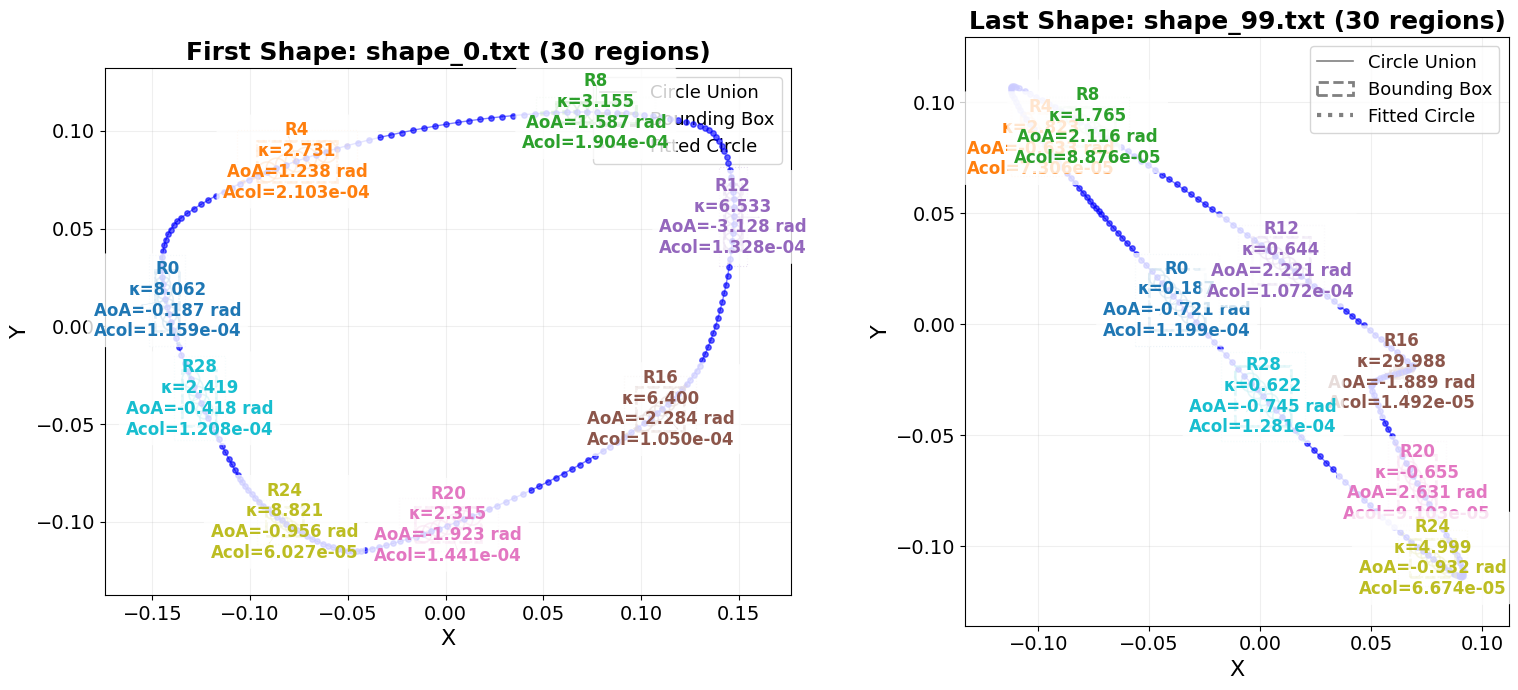


First shape: shape_0.txt
  Vertices: 204
  Regions: 30
    Region 0: 7 pts, 7 circles, Normal: (-0.9826, -0.1858), Tangent: (-0.1858, 0.9826), Fitted: r=0.124036, κ=8.062182, AoA=-0.1869 rad, Aunion=2.280710e-04, Acollect=1.159354e-04
    Region 1: 7 pts, 7 circles, Normal: (-0.9864, 0.1645), Tangent: (0.1645, 0.9864), Fitted: r=0.041281, κ=24.224335, AoA=0.1652 rad, Aunion=1.429334e-04, Acollect=7.396837e-05
    Region 2: 7 pts, 7 circles, Normal: (-0.6385, 0.7696), Tangent: (0.7696, 0.6385), Fitted: r=0.046139, κ=21.673452, AoA=0.8782 rad, Aunion=1.788841e-04, Acollect=9.203261e-05
    Region 3: 7 pts, 7 circles, Normal: (-0.4391, 0.8984), Tangent: (0.8984, 0.4391), Fitted: r=0.223342, κ=4.477442, AoA=1.1162 rad, Aunion=3.259834e-04, Acollect=1.646714e-04
    Region 4: 7 pts, 7 circles, Normal: (-0.3264, 0.9452), Tangent: (0.9452, 0.3264), Fitted: r=0.366123, κ=2.731324, AoA=1.2384 rad, Aunion=4.177493e-04, Acollect=2.103146e-04
    Region 5: 7 pts, 7 circles, Normal: (-0.2392, 0.97

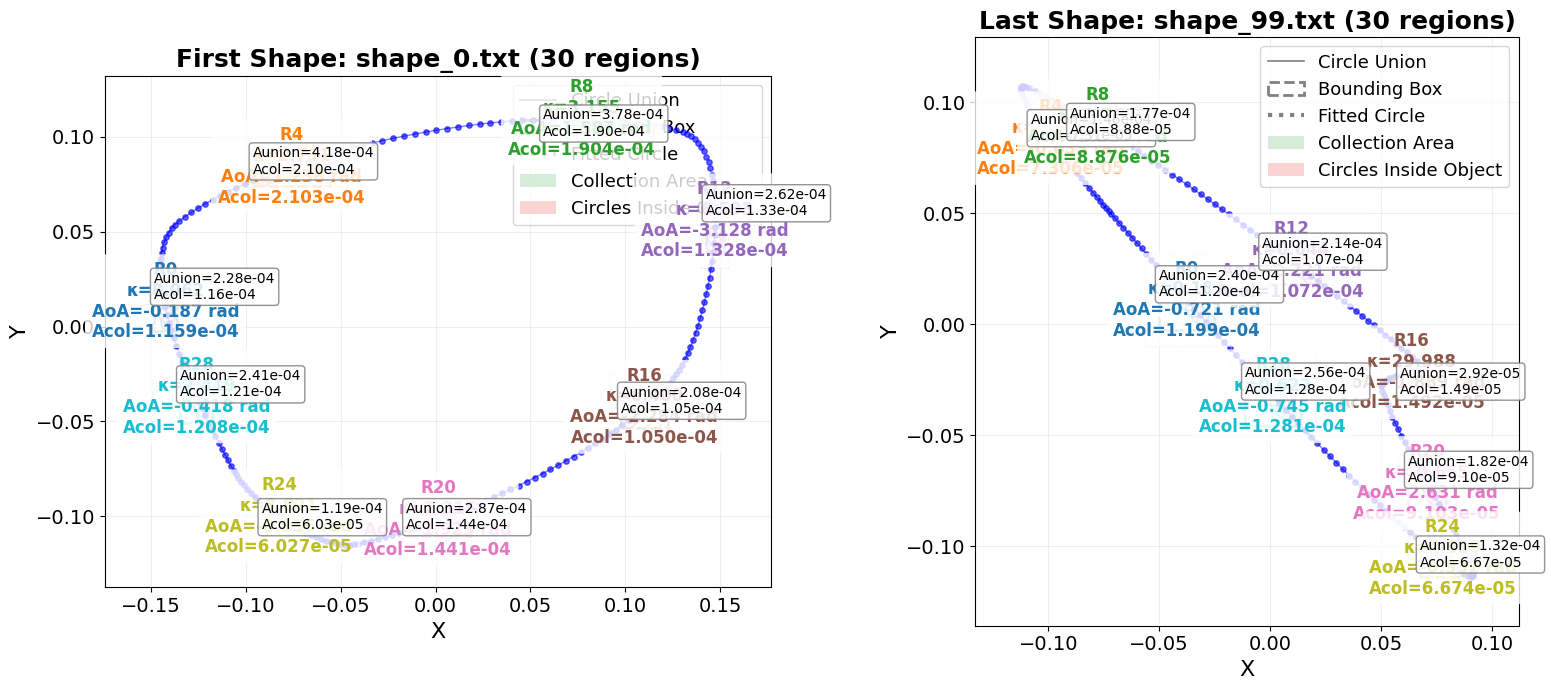


First shape: shape_0.txt
  Vertices: 204
  Regions: 30
    Region 0: 7 pts, 7 circles, Normal: (-0.9826, -0.1858), Tangent: (-0.1858, 0.9826), Fitted: r=0.124036, κ=8.062182, AoA=-0.1869 rad, Aunion=2.280710e-04, Acollect=1.159354e-04
    Region 1: 7 pts, 7 circles, Normal: (-0.9864, 0.1645), Tangent: (0.1645, 0.9864), Fitted: r=0.041281, κ=24.224335, AoA=0.1652 rad, Aunion=1.429334e-04, Acollect=7.396837e-05
    Region 2: 7 pts, 7 circles, Normal: (-0.6385, 0.7696), Tangent: (0.7696, 0.6385), Fitted: r=0.046139, κ=21.673452, AoA=0.8782 rad, Aunion=1.788841e-04, Acollect=9.203261e-05
    Region 3: 7 pts, 7 circles, Normal: (-0.4391, 0.8984), Tangent: (0.8984, 0.4391), Fitted: r=0.223342, κ=4.477442, AoA=1.1162 rad, Aunion=3.259834e-04, Acollect=1.646714e-04
    Region 4: 7 pts, 7 circles, Normal: (-0.3264, 0.9452), Tangent: (0.9452, 0.3264), Fitted: r=0.366123, κ=2.731324, AoA=1.2384 rad, Aunion=4.177493e-04, Acollect=2.103146e-04
    Region 5: 7 pts, 7 circles, Normal: (-0.2392, 0.97

In [41]:
from matplotlib.path import Path
from matplotlib.colors import ListedColormap

def divide_vertices_into_regions(vertices, max_regions=20, min_points_per_region=5):
    """
    Divide vertices into consecutive regions with constraints:
    - At most max_regions regions
    - At least min_points_per_region points per region
    
    Returns: list of region arrays, where each region is a subset of consecutive vertices
    """
    num_vertices = len(vertices)
    
    # If we can't satisfy constraints, just return single region
    if num_vertices < min_points_per_region or max_regions <= 1:
        return [vertices]
    
    # Choose as many regions as possible while satisfying the minimum points constraint
    num_regions = min(max_regions, num_vertices // min_points_per_region)
    
    if num_regions <= 1:
        return [vertices]
    
    # Split points as evenly as possible across regions
    # Sizes differ by at most 1 point, avoiding a large final region
    base_size = num_vertices // num_regions
    remainder = num_vertices % num_regions
    
    regions = []
    start_idx = 0
    
    for region_idx in range(num_regions):
        region_size = base_size + (1 if region_idx < remainder else 0)
        end_idx = start_idx + region_size
        
        region = vertices[start_idx:end_idx]
        if len(region) > 0:
            regions.append(region)
        start_idx = end_idx
    
    return regions

def compute_region_circle_union(region_vertices, all_vertices):
    """
    Compute a union of circles for a region where each point gets a circle.
    The radius for each point is the average distance to its two neighbors.
    
    Parameters:
    - region_vertices: Nx2 array of vertices in this region
    - all_vertices: Full vertex array (needed to find proper neighbors for edge points)
    
    Returns:
    - circles: list of dicts with keys 'center' (x,y) and 'radius'
    - bounding_box: (min_x, max_x, min_y, max_y) for the union
    """
    circles = []
    n_region = len(region_vertices)
    n_total = len(all_vertices)
    
    # Find starting index of this region in the full vertex array
    region_start_idx = None
    for i in range(n_total - n_region + 1):
        if np.allclose(all_vertices[i], region_vertices[0]) and \
           np.allclose(all_vertices[min(i + n_region - 1, n_total - 1)], region_vertices[-1]):
            region_start_idx = i
            break
    
    if region_start_idx is None:
        # Fallback: use region vertices only
        for local_idx, center in enumerate(region_vertices):
            # Calculate distances to neighbors within region
            if n_region == 1:
                radius = 0.01  # Small default for single point
            elif local_idx == 0:
                dist_next = np.linalg.norm(region_vertices[1] - center)
                radius = dist_next
            elif local_idx == n_region - 1:
                dist_prev = np.linalg.norm(region_vertices[-2] - center)
                radius = dist_prev
            else:
                dist_prev = np.linalg.norm(region_vertices[local_idx - 1] - center)
                dist_next = np.linalg.norm(region_vertices[local_idx + 1] - center)
                radius = (dist_prev + dist_next) / 2.0
            
            circles.append({'center': tuple(center), 'radius': radius})
    else:
        # Use global indices for proper neighbor calculation (handles wrap-around)
        for local_idx in range(n_region):
            global_idx = region_start_idx + local_idx
            center = region_vertices[local_idx]
            
            # Get neighbors with wrap-around
            prev_idx = (global_idx - 1) % n_total
            next_idx = (global_idx + 1) % n_total
            
            dist_prev = np.linalg.norm(all_vertices[prev_idx] - center)
            dist_next = np.linalg.norm(all_vertices[next_idx] - center)
            radius = (dist_prev + dist_next) / 2.0
            
            circles.append({'center': tuple(center), 'radius': radius})
    
    # Compute bounding box for the circle union
    all_radii = np.array([c['radius'] for c in circles])
    all_centers = np.array([c['center'] for c in circles])
    
    min_x = np.min(all_centers[:, 0] - all_radii)
    max_x = np.max(all_centers[:, 0] + all_radii)
    min_y = np.min(all_centers[:, 1] - all_radii)
    max_y = np.max(all_centers[:, 1] + all_radii)
    
    bounding_box = (min_x, max_x, min_y, max_y)
    
    return circles, bounding_box

def estimate_circle_union_area(circles, object_vertices, integration_samples=250):
    """
    Numerically estimate the total collection area for a union of circles.
    Collection area = area of circles NOT inside the object polygon.
    
    Parameters:
    - circles: list of dicts with 'center' and 'radius'
    - object_vertices: Nx2 array of object boundary vertices
    - integration_samples: grid resolution for numerical integration
    
    Returns:
    - union_area: total area covered by circle union
    - collection_area: area of circles outside object (for data collection)
    """
    if not circles:
        return 0.0, 0.0
    
    # Get bounding box for all circles
    all_radii = np.array([c['radius'] for c in circles])
    all_centers = np.array([c['center'] for c in circles])
    
    min_x = np.min(all_centers[:, 0] - all_radii)
    max_x = np.max(all_centers[:, 0] + all_radii)
    min_y = np.min(all_centers[:, 1] - all_radii)
    max_y = np.max(all_centers[:, 1] + all_radii)
    
    width = max_x - min_x
    height = max_y - min_y
    
    if width <= 0 or height <= 0:
        return 0.0, 0.0
    
    # Create integration grid
    x_edges = np.linspace(min_x, max_x, integration_samples + 1)
    y_edges = np.linspace(min_y, max_y, integration_samples + 1)
    x_mid = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_mid = 0.5 * (y_edges[:-1] + y_edges[1:])
    
    xx, yy = np.meshgrid(x_mid, y_mid)
    sample_points = np.column_stack((xx.ravel(), yy.ravel()))
    
    # Check which points are inside any circle
    in_circle_union = np.zeros(len(sample_points), dtype=bool)
    for circle in circles:
        cx, cy = circle['center']
        r = circle['radius']
        dist_sq = (sample_points[:, 0] - cx)**2 + (sample_points[:, 1] - cy)**2
        in_circle_union |= (dist_sq <= r**2)
    
    # Check which points are inside object
    polygon_path = Path(object_vertices, closed=True)
    inside_object = polygon_path.contains_points(sample_points)
    
    # Collection area: in circles but NOT in object
    in_collection = in_circle_union & ~inside_object
    
    dx = width / integration_samples
    dy = height / integration_samples
    cell_area = dx * dy
    
    union_area = np.sum(in_circle_union) * cell_area
    collection_area = np.sum(in_collection) * cell_area
    
    return union_area, collection_area

def shade_circle_union_area(ax, circles, object_vertices, integration_samples=80,
                            inside_color='#ef5350', outside_color='#66bb6a',
                            inside_alpha=0.22, outside_alpha=0.12):
    """
    Shade circle union areas: red for circles inside object, green for collection area.
    """
    if not circles:
        return
    
    # Get bounding box
    all_radii = np.array([c['radius'] for c in circles])
    all_centers = np.array([c['center'] for c in circles])
    
    min_x = np.min(all_centers[:, 0] - all_radii)
    max_x = np.max(all_centers[:, 0] + all_radii)
    min_y = np.min(all_centers[:, 1] - all_radii)
    max_y = np.max(all_centers[:, 1] + all_radii)
    
    width = max_x - min_x
    height = max_y - min_y
    
    if width <= 0 or height <= 0:
        return
    
    x_edges = np.linspace(min_x, max_x, integration_samples + 1)
    y_edges = np.linspace(min_y, max_y, integration_samples + 1)
    x_mid = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_mid = 0.5 * (y_edges[:-1] + y_edges[1:])
    
    xx, yy = np.meshgrid(x_mid, y_mid)
    sample_points = np.column_stack((xx.ravel(), yy.ravel()))
    
    # Check circle union
    in_circle_union = np.zeros(len(sample_points), dtype=bool)
    for circle in circles:
        cx, cy = circle['center']
        r = circle['radius']
        dist_sq = (sample_points[:, 0] - cx)**2 + (sample_points[:, 1] - cy)**2
        in_circle_union |= (dist_sq <= r**2)
    
    # Check object
    polygon_path = Path(object_vertices, closed=True)
    inside_object = polygon_path.contains_points(sample_points)
    
    in_circle_union = in_circle_union.reshape(len(y_mid), len(x_mid))
    inside_object = inside_object.reshape(len(y_mid), len(x_mid))
    
    # Areas: circles inside object vs. collection area (circles outside object)
    circles_inside_obj = in_circle_union & inside_object
    circles_outside_obj = in_circle_union & ~inside_object
    
    inside_vals = np.ma.masked_where(~circles_inside_obj, np.ones_like(circles_inside_obj, dtype=float))
    outside_vals = np.ma.masked_where(~circles_outside_obj, np.ones_like(circles_outside_obj, dtype=float))
    
    ax.pcolormesh(x_edges, y_edges, outside_vals, shading='flat',
                  cmap=ListedColormap([outside_color]), alpha=outside_alpha, zorder=1)
    ax.pcolormesh(x_edges, y_edges, inside_vals, shading='flat',
                  cmap=ListedColormap([inside_color]), alpha=inside_alpha, zorder=2)

def compute_region_properties(region_vertices, object_vertices=None, integration_samples=250):
    """
    Compute region properties using circle union instead of bounding box.
    
    Returns: (circles, bbox, normal, tangent, fitted_circle, aoa, union_area, collection_area) where:
    - circles: list of dicts {'center': (x, y), 'radius': r} for each point in region
    - bbox: (min_x, max_x, min_y, max_y) bounding box of circle union
    - normal: outward-facing normal vector
    - tangent: tangent vector
    - fitted_circle: single fitted circle for curvature estimation {'center': (cx, cy), 'radius': signed_r}
    - aoa: local angle of attack in radians
    - union_area: total area of circle union
    - collection_area: area available for data collection (circles outside object)
    """
    # Compute circle union for this region
    circles, bbox = compute_region_circle_union(region_vertices, object_vertices)
    
    # Region center for normal computation
    region_center = np.mean(region_vertices, axis=0)
    
    # Outward-facing normal
    if len(region_vertices) >= 2:
        # Use first and last points to estimate tangent
        tangent = region_vertices[-1] - region_vertices[0]
        tangent_norm = np.linalg.norm(tangent)
        if tangent_norm > 1e-10:
            tangent = tangent / tangent_norm
            # Normal is perpendicular to tangent
            normal = np.array([-tangent[1], tangent[0]])
            
            # Ensure outward facing by checking against centroid
            center_dir = region_center / (np.linalg.norm(region_center) + 1e-10)
            if np.dot(normal, center_dir) < 0:
                normal = -normal
        else:
            normal = np.array([1.0, 0.0])
    else:
        normal = np.array([1.0, 0.0])
    
    # Tangent from outward normal using right-hand rule in 2D: (-z × n)
    tangent_vec = np.array([normal[1], -normal[0]])
    
    # Fit circle to region vertices for curvature estimation
    try:
        from circle_fit import taubinSVD
        xc, yc, radius, sigma = taubinSVD(region_vertices)
        circle_center = np.array([xc, yc])
    except Exception as e:
        # Fallback: use centroid as center and mean distance as radius
        circle_center = region_center
        radius = np.mean(np.linalg.norm(region_vertices - circle_center, axis=1))
    
    # Compute signed radius
    vec_to_circle = circle_center - region_center
    dot_product = np.dot(normal, vec_to_circle)
    signed_radius = radius if dot_product < 0 else -radius
    
    fitted_circle = {'center': tuple(circle_center), 'radius': signed_radius}
    
    # Compute local angle of attack
    aoa_rad = np.pi - np.arctan2(normal[1], normal[0])
    if aoa_rad > np.pi:
        aoa_rad -= 2 * np.pi
    elif aoa_rad <= -np.pi:
        aoa_rad += 2 * np.pi
    
    # Compute collection area using circle union
    union_area, collection_area = estimate_circle_union_area(
        circles=circles,
        object_vertices=object_vertices,
        integration_samples=integration_samples
    )
    
    return circles, bbox, normal, tangent_vec, fitted_circle, aoa_rad, union_area, collection_area

def process_sparta_folder(sparta_folder, output_metadata_folder=None, max_regions=10, min_points_per_region=10,
                         integration_samples=250):
    """
    Process all SPARTA files in a folder:
    - Divide nodes into regions (at most max_regions, at least min_points_per_region each)
    - Calculate circle unions and normals for each region
    - Save metadata files with region properties
    
    Parameters:
    - sparta_folder: Path to folder containing SPARTA .txt files
    - output_metadata_folder: Path to save metadata (default: sparta_folder/region_metadata)
    - max_regions: Maximum number of regions per shape (default: 10)
    - min_points_per_region: Minimum points per region (default: 10)
    - integration_samples: Numerical integration resolution for area metrics
    """
    if output_metadata_folder is None:
        output_metadata_folder = os.path.join(sparta_folder, 'region_metadata')
    
    if not os.path.exists(output_metadata_folder):
        os.makedirs(output_metadata_folder)
        print(f"Created output folder: {output_metadata_folder}")
    
    # Get all SPARTA files (exclude metadata files)
    sparta_files = sorted([f for f in os.listdir(sparta_folder) 
                          if f.endswith('.txt') and '_metadata' not in f])
    
    print(f"Found {len(sparta_files)} SPARTA files to process")
    print(f"Max regions: {max_regions}, Min points per region: {min_points_per_region}")
    print(f"Integration samples: {integration_samples}")
    print(f"Region definition: Circle union (one circle per point)\n")
    
    for file_idx, sparta_file in enumerate(sparta_files):
        sparta_path = os.path.join(sparta_folder, sparta_file)
        points, lines = read_sparta_file(sparta_path)
        
        if not points:
            print(f"  Skipped {sparta_file}: No points found")
            continue
        
        # Convert points dict to ordered array (object polygon vertices)
        vertices = np.array([points[i] for i in sorted(points.keys())])
        
        # Divide into regions
        regions = divide_vertices_into_regions(vertices, max_regions, min_points_per_region)
        
        # Compute properties for each region
        all_circles = []
        bboxes = []
        normals = []
        tangents = []
        fitted_circles = []
        aoas = []
        union_areas = []
        collection_areas = []

        for region in regions:
            circles, bbox, normal, tangent_vec, fitted_circle, aoa, union_area, collection_area = compute_region_properties(
                region_vertices=region,
                object_vertices=vertices,
                integration_samples=integration_samples
            )
            all_circles.append(circles)
            bboxes.append(bbox)
            normals.append(normal)
            tangents.append(tangent_vec)
            fitted_circles.append(fitted_circle)
            aoas.append(aoa)
            union_areas.append(union_area)
            collection_areas.append(collection_area)
        
        # Save metadata file
        base_name = os.path.splitext(sparta_file)[0]
        metadata_filename = f"{base_name}_region_metadata.txt"
        metadata_path = os.path.join(output_metadata_folder, metadata_filename)
        
        with open(metadata_path, 'w') as f:
            f.write(f"Region Metadata for: {sparta_file}\n")
            f.write("=" * 80 + "\n\n")
            f.write("REGION DEFINITION: Circle union (one circle per point)\n")
            f.write("  Each point gets a circle with radius = average distance to neighbors\n\n")
            
            f.write(f"Total vertices: {len(vertices)}\n")
            f.write(f"Number of regions: {len(regions)}\n")
            f.write(f"Points per region:\n")
            for region_idx, region in enumerate(regions):
                f.write(f"  Region {region_idx}: {len(region)} points\n")
            f.write("\n")
            
            f.write("REGION SUMMARY:\n")
            f.write("Region_Index,Num_Points,BBox_Min_X,BBox_Max_X,BBox_Min_Y,BBox_Max_Y,Normal_X,Normal_Y,Tangent_X,Tangent_Y,Fitted_Circle_X,Fitted_Circle_Y,Fitted_Circle_Radius,Local_AoA_Rad,Union_Area,Collection_Area\n")
            for region_idx, (region, circles, bbox, normal, tangent_vec, fitted_circle, aoa, union_area, collection_area) in enumerate(
                zip(regions, all_circles, bboxes, normals, tangents, fitted_circles, aoas, union_areas, collection_areas)
            ):
                min_x, max_x, min_y, max_y = bbox
                fcx, fcy = fitted_circle['center']
                fr = fitted_circle['radius']
                f.write(f"{region_idx},{len(region)},{min_x:.10e},{max_x:.10e},{min_y:.10e},"
                       f"{max_y:.10e},{normal[0]:.10f},{normal[1]:.10f},{tangent_vec[0]:.10f},{tangent_vec[1]:.10f},"
                       f"{fcx:.10e},{fcy:.10e},{fr:.10e},{aoa:.8e},{union_area:.8e},{collection_area:.8e}\n")
            
            # Write detailed circle data for each region
            f.write("\nDETAILED CIRCLE DATA:\n")
            for region_idx, circles in enumerate(all_circles):
                f.write(f"\nRegion {region_idx} ({len(circles)} circles):\n")
                f.write("Circle_Index,Center_X,Center_Y,Radius\n")
                for circle_idx, circle in enumerate(circles):
                    cx, cy = circle['center']
                    r = circle['radius']
                    f.write(f"{circle_idx},{cx:.10e},{cy:.10e},{r:.10e}\n")
        
        if (file_idx + 1) % 10 == 0 or file_idx == len(sparta_files) - 1:
            print(f"  [{file_idx + 1}/{len(sparta_files)}] Processed {sparta_file} ({len(regions)} regions)")
    
    print(f"\n✓ Processing complete!")
    print(f"  Total files processed: {len(sparta_files)}")
    print(f"  Metadata saved to: {output_metadata_folder}")

# ####### STEP 3 #######

# # Example usage - process SPARTA files and create region metadata
# sparta_folder = "shapes/dataset_2026-02-06_09_28_35/sparta_converted"
# if os.path.exists(sparta_folder):
#     process_sparta_folder(sparta_folder, max_regions=30, min_points_per_region=4, integration_samples=250)
# else:
#     print(f"SPARTA folder not found at: {sparta_folder}")

# #######################
def read_region_metadata(metadata_filepath):
    """Read region metadata file and extract region properties including circle union data."""
    regions_data = []
    
    with open(metadata_filepath, 'r') as f:
        lines = f.readlines()
    
    # Find start of region summary data
    summary_start_idx = 0
    for idx, line in enumerate(lines):
        if 'Region_Index' in line and 'Num_Points' in line:
            summary_start_idx = idx + 1
            break
    
    # Parse region summary
    idx = summary_start_idx
    while idx < len(lines):
        line = lines[idx].strip()
        if not line or line.startswith('#') or line.startswith('DETAILED'):
            break
        
        parts = line.split(',')
        if len(parts) >= 16:
            try:
                region_idx = int(parts[0])
                num_points = int(parts[1])
                min_x = float(parts[2])
                max_x = float(parts[3])
                min_y = float(parts[4])
                max_y = float(parts[5])
                normal_x = float(parts[6])
                normal_y = float(parts[7])
                tangent_x = float(parts[8])
                tangent_y = float(parts[9])
                fitted_cx = float(parts[10])
                fitted_cy = float(parts[11])
                fitted_r = float(parts[12])
                aoa = float(parts[13])
                union_area = float(parts[14])
                collection_area = float(parts[15])
                
                regions_data.append({
                    'index': region_idx,
                    'num_points': num_points,
                    'bbox': (min_x, max_x, min_y, max_y),
                    'normal': np.array([normal_x, normal_y]),
                    'tangent': np.array([tangent_x, tangent_y]),
                    'fitted_circle': {'center': (fitted_cx, fitted_cy), 'radius': fitted_r},
                    'aoa': aoa,
                    'union_area': union_area,
                    'collection_area': collection_area,
                    'circles': []  # Will be populated from detailed section
                })
            except (ValueError, IndexError):
                pass
        idx += 1
    
    # Parse detailed circle data
    idx = 0
    while idx < len(lines):
        line = lines[idx].strip()
        if line.startswith('Region ') and '(' in line and 'circles)' in line:
            # Extract region index
            region_idx = int(line.split()[1])
            # Skip header line
            idx += 2
            
            # Read circles for this region
            circles = []
            while idx < len(lines):
                line = lines[idx].strip()
                if not line or line.startswith('Region '):
                    break
                
                parts = line.split(',')
                if len(parts) == 4:
                    try:
                        cx = float(parts[1])
                        cy = float(parts[2])
                        r = float(parts[3])
                        circles.append({'center': (cx, cy), 'radius': r})
                    except ValueError:
                        pass
                idx += 1
            
            # Assign circles to corresponding region
            for region_data in regions_data:
                if region_data['index'] == region_idx:
                    region_data['circles'] = circles
                    break
        else:
            idx += 1
    
    return regions_data

def draw_circle_arc(ax, center, radius, bbox_bounds, draw_bounds, color, linewidth=2, alpha=0.7, linestyle='--'):
    """
    Draw the full circle arc between the endpoints of the bounding box,
    visible within the extended drawing bounds.
    """
    cx, cy = center
    x_min, x_max, y_min, y_max = bbox_bounds
    draw_x_min, draw_x_max, draw_y_min, draw_y_max = draw_bounds
    
    # Generate circle points
    theta = np.linspace(0, 2*np.pi, 500)
    circle_x = cx + radius * np.cos(theta)
    circle_y = cy + radius * np.sin(theta)
    
    # Find indices where circle is within the extended drawing bounds
    in_draw_bounds = (circle_x >= draw_x_min) & (circle_x <= draw_x_max) & \
                     (circle_y >= draw_y_min) & (circle_y <= draw_y_max)
    
    if np.any(in_draw_bounds):
        # Find contiguous segments
        segments = []
        current_segment = []
        
        for i, in_view in enumerate(in_draw_bounds):
            if in_view:
                current_segment.append(i)
            else:
                if current_segment:
                    segments.append(current_segment)
                    current_segment = []
        
        if current_segment:
            segments.append(current_segment)
        
        # Draw each segment
        for segment in segments:
            if len(segment) > 1:
                seg_indices = segment
                ax.plot(circle_x[seg_indices], circle_y[seg_indices], 
                       color=color, linewidth=linewidth, alpha=alpha, linestyle=linestyle)
        
        # Draw the actual bounding box in a lighter shade to show comparison
        rect_actual = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                        fill=False, edgecolor=color, linewidth=1.5, 
                                        alpha=0.4, linestyle=':', zorder=1)
        ax.add_patch(rect_actual)
        
        # Draw the extended drawing bounds as reference
        rect_draw = patches.Rectangle((draw_x_min, draw_y_min), draw_x_max - draw_x_min, draw_y_max - draw_y_min,
                                      fill=False, edgecolor=color, linewidth=0.8, 
                                      alpha=0.2, linestyle=':', zorder=0)
        ax.add_patch(rect_draw)

def plot_regions_for_shape(sparta_file, regions_data, title="Shape with Regions", ax=None, 
                           show_bbox=True, show_fitted_circle=True, show_circles=True, show_normal=True, show_tangent=False,
                           show_area_shading=False, area_plot_samples=80, plot_every_n_regions=1,
                           title_fontsize=18, axis_label_fontsize=16, tick_label_fontsize=14,
                           region_label_fontsize=12, area_text_fontsize=10, legend_fontsize=13):
    """
    Plot a shape with its circle union regions.
    
    Parameters:
    - sparta_file: tuple of (points_dict, lines_list)
    - regions_data: list of region dicts with circle union data
    - title: Title for the plot
    - ax: Matplotlib axes (creates new if None)
    - show_bbox: Whether to show bounding boxes (default: True)
    - show_fitted_circle: Whether to show fitted circle for curvature (default: True)
    - show_circles: Whether to show individual circles in the union (default: True)
    - show_normal: Whether to show normal vectors (default: True)
    - show_tangent: Whether to show tangent vectors (default: False)
    - show_area_shading: Shade collection area for validation
    - area_plot_samples: Grid resolution for area shading visualization
    - plot_every_n_regions: Plot only every Nth region (default: 1 = plot all)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))
    
    plot_every_n_regions = max(1, int(plot_every_n_regions))
    
    points, lines = sparta_file
    object_vertices = np.array([points[i] for i in sorted(points.keys())]) if points else None
    
    # Plot edges
    for p1, p2 in lines:
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'b-', linewidth=1, alpha=0.5, zorder=3)
    
    # Plot vertices
    if points:
        vertices = np.array(list(points.values()))
        ax.scatter(vertices[:, 0], vertices[:, 1], color='blue', s=15, zorder=6, alpha=0.6)
    
    # Color for each region
    colors = plt.cm.tab10(np.linspace(0, 1, len(regions_data)))
    
    # Calculate axis bounds based on shape vertices
    if points:
        vertices = np.array(list(points.values()))
        x_min, x_max = np.min(vertices[:, 0]), np.max(vertices[:, 0])
        y_min, y_max = np.min(vertices[:, 1]), np.max(vertices[:, 1])
        
        # Add padding (10% of shape size)
        x_range = x_max - x_min
        y_range = y_max - y_min
        padding = 0.1
        x_min -= padding * x_range
        x_max += padding * x_range
        y_min -= padding * y_range
        y_max += padding * y_range
        
        visible_bounds = (x_min, x_max, y_min, y_max)
    else:
        visible_bounds = (-0.01, 0.01, -0.01, 0.01)
    
    # Plot regions with circle unions
    for region_idx, region_props in enumerate(regions_data):
        if (region_idx % plot_every_n_regions) != 0:
            continue
        bbox = region_props['bbox']
        normal = region_props['normal']
        tangent = region_props.get('tangent')
        fitted_circle = region_props.get('fitted_circle')
        circles = region_props.get('circles', [])
        aoa = region_props.get('aoa')
        union_area = region_props.get('union_area')
        collection_area = region_props.get('collection_area')
        min_x, max_x, min_y, max_y = bbox

        # Optional area shading for verification
        if show_area_shading and object_vertices is not None and circles:
            shade_circle_union_area(
                ax,
                circles=circles,
                object_vertices=object_vertices,
                integration_samples=area_plot_samples
            )
        
        # Plot individual circles in the union
        if show_circles and circles:
            for circle in circles:
                cx, cy = circle['center']
                r = circle['radius']
                circle_patch = plt.Circle((cx, cy), r, fill=False, edgecolor=colors[region_idx],
                                         linewidth=1.2, alpha=0.6, linestyle='-', zorder=4)
                ax.add_patch(circle_patch)
        
        # Plot bounding box
        if show_bbox:
            rect = patches.Rectangle((min_x, min_y), max_x - min_x, max_y - min_y,
                                     fill=False, edgecolor=colors[region_idx], linewidth=2.0, 
                                     alpha=0.5, linestyle='--', zorder=7)
            ax.add_patch(rect)
        
        # Plot fitted circle for curvature visualization
        if show_fitted_circle and fitted_circle is not None:
            cx, cy = fitted_circle['center']
            r = abs(fitted_circle['radius'])
            bbox_bounds = (min_x, max_x, min_y, max_y)
            
            # Calculate enlarged drawing bounds
            bbox_width = max_x - min_x
            bbox_height = max_y - min_y
            expand_x = bbox_width * 0.5 / 2
            expand_y = bbox_height * 0.5 / 2
            draw_bounds = (min_x - expand_x, max_x + expand_x, 
                          min_y - expand_y, max_y + expand_y)
            
            draw_circle_arc(ax, (cx, cy), r, bbox_bounds, draw_bounds,
                          color=colors[region_idx], linewidth=3, alpha=0.8, linestyle=':')
        
        # Plot outward-facing normal as quiver arrow
        if show_normal:
            box_center_x = (min_x + max_x) / 2
            box_center_y = (min_y + max_y) / 2
            
            shape_size = max(visible_bounds[1] - visible_bounds[0], 
                            visible_bounds[3] - visible_bounds[2])
            scale = shape_size / 25
            
            ax.quiver(box_center_x, box_center_y, normal[0] * scale, normal[1] * scale,
                     angles='xy', scale_units='xy', scale=1, 
                     color=colors[region_idx], alpha=0.9, zorder=8, width=0.0008,
                     headwidth=3, headlength=4)

        # Plot tangent as quiver arrow
        if show_tangent:
            box_center_x = (min_x + max_x) / 2
            box_center_y = (min_y + max_y) / 2
            
            shape_size = max(visible_bounds[1] - visible_bounds[0], 
                            visible_bounds[3] - visible_bounds[2])
            scale = shape_size / 25
            
            tangent_vec = tangent if tangent is not None else np.array([normal[1], -normal[0]])
            ax.quiver(box_center_x, box_center_y, tangent_vec[0] * scale, tangent_vec[1] * scale,
                     angles='xy', scale_units='xy', scale=1,
                     color=colors[region_idx], alpha=0.75, zorder=8, width=0.0008,
                     headwidth=3, headlength=4, linestyle='--')
        
        # Add region label
        box_center_x = (min_x + max_x) / 2
        box_center_y = (min_y + max_y) / 2
        
        curvature_str = ""
        if fitted_circle is not None and fitted_circle['radius'] != 0:
            curvature = 1.0 / fitted_circle['radius']
            curvature_str = f"\nκ={curvature:.3f}"
        
        aoa_str = ""
        if aoa is not None:
            aoa_str = f"\nAoA={aoa:.3f} rad"

        collection_area_str = ""
        if collection_area is not None:
            collection_area_str = f"\nAcol={collection_area:.3e}"
        
        label_text = f'R{region_idx}{curvature_str}{aoa_str}{collection_area_str}'
        ax.text(box_center_x, box_center_y, label_text,
               fontsize=region_label_fontsize, ha='center', va='center', fontweight='bold', color=colors[region_idx], zorder=10,
               bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='none'))

        # Optional detailed area values
        if show_area_shading and union_area is not None and collection_area is not None:
            area_text = f"Aunion={union_area:.2e}\nAcol={collection_area:.2e}"
            ax.text(min_x, max_y, area_text,
                    fontsize=area_text_fontsize, ha='left', va='top', color='black', zorder=11,
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='gray'))
    
    # Set axis limits
    x_min, x_max, y_min, y_max = visible_bounds
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.set_title(title, fontsize=title_fontsize, fontweight='bold')
    ax.set_xlabel('X', fontsize=axis_label_fontsize)
    ax.set_ylabel('Y', fontsize=axis_label_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize)
    
    # Add legend
    handles = []
    labels = []
    if show_circles:
        handles.append(plt.Line2D([0], [0], color='gray', linewidth=1.2, linestyle='-'))
        labels.append('Circle Union')
    if show_bbox:
        handles.append(patches.Rectangle((0, 0), 1, 1, fill=False, edgecolor='gray', linewidth=2.0, linestyle='--'))
        labels.append('Bounding Box')
    if show_fitted_circle:
        handles.append(plt.Line2D([0], [0], color='gray', linewidth=3, linestyle=':'))
        labels.append('Fitted Circle')
    if show_area_shading:
        handles.append(patches.Patch(facecolor='#66bb6a', alpha=0.25))
        labels.append('Collection Area')
        handles.append(patches.Patch(facecolor='#ef5350', alpha=0.25))
        labels.append('Circles Inside Object')
    if handles:
        ax.legend(handles, labels, loc='upper right', fontsize=legend_fontsize)

def plot_regions_comparison(sparta_folder, region_metadata_folder=None, show_bbox=True, 
                            show_fitted_circle=True, show_circles=True, show_normal=True, show_tangent=False,
                            show_area_shading=False, area_plot_samples=80, plot_every_n_regions=1):
    """
    Plot the first and last shapes with their circle union regions.
    """
    if region_metadata_folder is None:
        region_metadata_folder = os.path.join(sparta_folder, 'region_metadata')
    
    sparta_files = sorted([f for f in os.listdir(sparta_folder) 
                          if f.endswith('.txt') and '_metadata' not in f])
    
    if len(sparta_files) < 2:
        print(f"Need at least 2 SPARTA files to plot comparison")
        return
    
    metadata_files = sorted([f for f in os.listdir(region_metadata_folder) 
                           if f.endswith('_region_metadata.txt')])
    
    metadata_map = {}
    for metadata_file in metadata_files:
        base_name = metadata_file.replace('_region_metadata.txt', '')
        metadata_map[base_name] = metadata_file
    
    first_sparta_file = sparta_files[0]
    last_sparta_file = sparta_files[-1]
    
    first_base_name = os.path.splitext(first_sparta_file)[0]
    last_base_name = os.path.splitext(last_sparta_file)[0]
    
    first_metadata_file = metadata_map.get(first_base_name)
    last_metadata_file = metadata_map.get(last_base_name)
    
    if first_metadata_file is None or last_metadata_file is None:
        print(f"Error: Could not find matching metadata files")
        return
    
    first_sparta_path = os.path.join(sparta_folder, first_sparta_file)
    first_metadata_path = os.path.join(region_metadata_folder, first_metadata_file)
    
    first_points, first_lines = read_sparta_file(first_sparta_path)
    first_regions = read_region_metadata(first_metadata_path)
    
    last_sparta_path = os.path.join(sparta_folder, last_sparta_file)
    last_metadata_path = os.path.join(region_metadata_folder, last_metadata_file)
    
    last_points, last_lines = read_sparta_file(last_sparta_path)
    last_regions = read_region_metadata(last_metadata_path)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    plot_regions_for_shape((first_points, first_lines), first_regions,
                          f"First Shape: {first_sparta_file} ({len(first_regions)} regions)", ax=ax1,
                          show_bbox=show_bbox, show_fitted_circle=show_fitted_circle, show_circles=show_circles,
                          show_normal=show_normal, show_tangent=show_tangent,
                          show_area_shading=show_area_shading, area_plot_samples=area_plot_samples,
                          plot_every_n_regions=plot_every_n_regions)
    plot_regions_for_shape((last_points, last_lines), last_regions,
                          f"Last Shape: {last_sparta_file} ({len(last_regions)} regions)", ax=ax2,
                          show_bbox=show_bbox, show_fitted_circle=show_fitted_circle, show_circles=show_circles,
                          show_normal=show_normal, show_tangent=show_tangent,
                          show_area_shading=show_area_shading, area_plot_samples=area_plot_samples,
                          plot_every_n_regions=plot_every_n_regions)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nFirst shape: {first_sparta_file}")
    print(f"  Vertices: {len(first_points)}")
    print(f"  Regions: {len(first_regions)}")
    for region in first_regions:
        min_x, max_x, min_y, max_y = region['bbox']
        fitted_circle = region.get('fitted_circle')
        aoa = region.get('aoa')
        union_area = region.get('union_area')
        collection_area = region.get('collection_area')
        num_circles = len(region.get('circles', []))
        tangent = region.get('tangent')
        tangent_info = f", Tangent: ({tangent[0]:.4f}, {tangent[1]:.4f})" if tangent is not None else ""
        fitted_info = ""
        if fitted_circle:
            r = fitted_circle['radius']
            curvature = 1.0 / r if r != 0 else float('inf')
            fitted_info = f", Fitted: r={r:.6f}, κ={curvature:.6f}"
        aoa_info = f", AoA={aoa:.4f} rad" if aoa is not None else ""
        area_info = f", Aunion={union_area:.6e}, Acollect={collection_area:.6e}" if union_area is not None else ""
        print(f"    Region {region['index']}: {region['num_points']} pts, {num_circles} circles, " + 
              f"Normal: ({region['normal'][0]:.4f}, {region['normal'][1]:.4f}){tangent_info}{fitted_info}{aoa_info}{area_info}")
    
    print(f"\nLast shape: {last_sparta_file}")
    print(f"  Vertices: {len(last_points)}")
    print(f"  Regions: {len(last_regions)}")
    for region in last_regions:
        min_x, max_x, min_y, max_y = region['bbox']
        fitted_circle = region.get('fitted_circle')
        aoa = region.get('aoa')
        union_area = region.get('union_area')
        collection_area = region.get('collection_area')
        num_circles = len(region.get('circles', []))
        tangent = region.get('tangent')
        tangent_info = f", Tangent: ({tangent[0]:.4f}, {tangent[1]:.4f})" if tangent is not None else ""
        fitted_info = ""
        if fitted_circle:
            r = fitted_circle['radius']
            curvature = 1.0 / r if r != 0 else float('inf')
            fitted_info = f", Fitted: r={r:.6f}, κ={curvature:.6f}"
        aoa_info = f", AoA={aoa:.4f} rad" if aoa is not None else ""
        area_info = f", Aunion={union_area:.6e}, Acollect={collection_area:.6e}" if union_area is not None else ""
        print(f"    Region {region['index']}: {region['num_points']} pts, {num_circles} circles, " + 
              f"Normal: ({region['normal'][0]:.4f}, {region['normal'][1]:.4f}){tangent_info}{fitted_info}{aoa_info}{area_info}")

# Example usage - plot regions comparison with different visualization options

####### STEP 4 #######
# Option 1: Show both bounding boxes and circle unions (default)
sparta_folder = "shapes/dataset_2026-02-06_09_28_35/sparta_converted"
region_metadata_folder = os.path.join(sparta_folder, 'region_metadata')
plot_every_n_regions = 4  # Increase to 3, 4, ... for less clutter
if os.path.exists(region_metadata_folder):
    print("=== Visualization: Circle Unions ===")
    plot_regions_comparison(sparta_folder, region_metadata_folder, 
                           show_bbox=True, show_fitted_circle=True, show_circles=True,
                           show_normal=True, show_tangent=False,
                           show_area_shading=False, area_plot_samples=100,
                           plot_every_n_regions=plot_every_n_regions)
else:
    print(f"Region metadata folder not found at: {region_metadata_folder}")

#########################

# Option 2: Show area shading for validation
plot_regions_comparison(sparta_folder, region_metadata_folder, 
                       show_bbox=True, show_fitted_circle=True, show_circles=True,
                       show_normal=True, show_tangent=True,
                       show_area_shading=True, area_plot_samples=120,
                       plot_every_n_regions=plot_every_n_regions)

# Option 3: Show only circle unions
# plot_regions_comparison(sparta_folder, region_metadata_folder, 
#                        show_bbox=False, show_fitted_circle=False, show_circles=True,
#                        show_normal=True, show_tangent=False,
#                        show_area_shading=False)


Generating circle with diameter: 3.048000e-01
  Number of points: 300
  Radius: 1.524000e-01

✓ Saved SPARTA file: argon_circle.txt

Processing regions with circle union definition...
✓ Saved region metadata: temp_metadata/argon_circle_region_metadata.txt
  Number of regions: 10

Creating visualization...



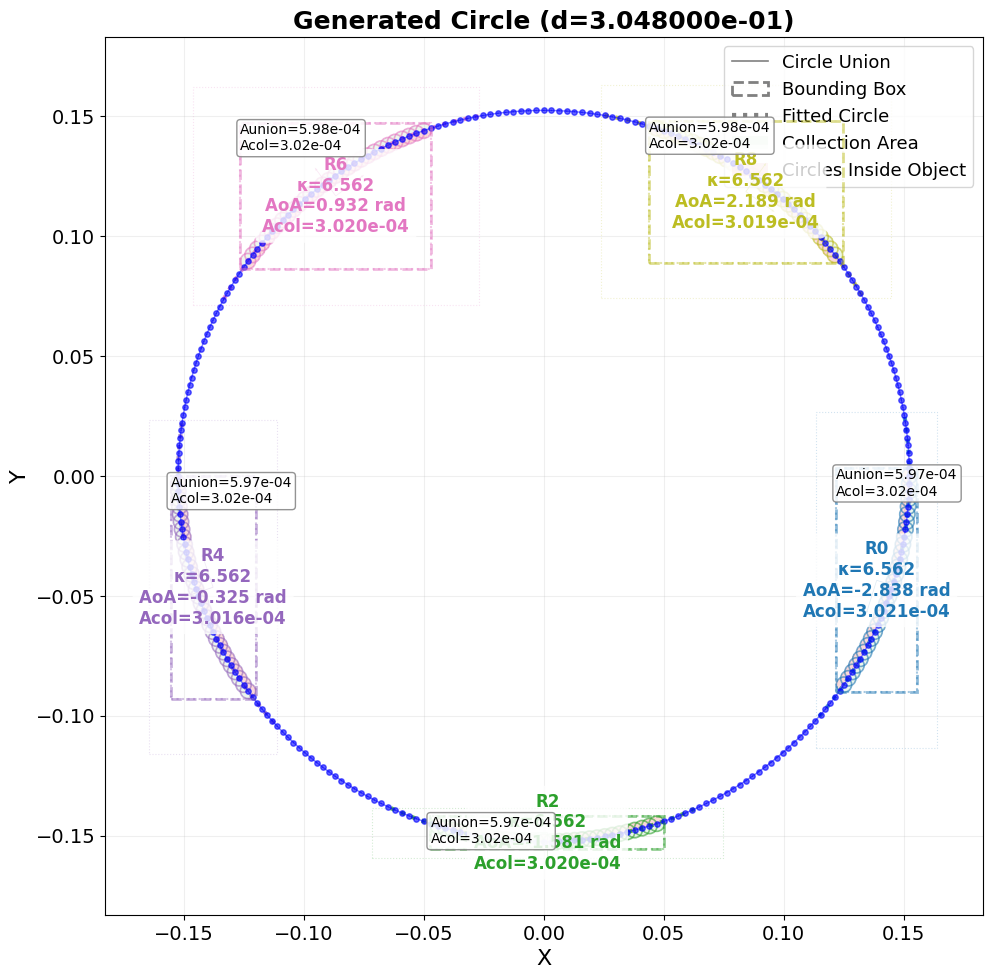


Circle generation complete!
  SPARTA file: argon_circle.txt
  Metadata file: temp_metadata/argon_circle_region_metadata.txt
  Regions: 10
    Region 0: 30 points, 30 circles
    Region 1: 30 points, 30 circles
    Region 2: 30 points, 30 circles
    Region 3: 30 points, 30 circles
    Region 4: 30 points, 30 circles
    Region 5: 30 points, 30 circles
    Region 6: 30 points, 30 circles
    Region 7: 30 points, 30 circles
    Region 8: 30 points, 30 circles
    Region 9: 30 points, 30 circles


In [40]:
def generate_circle_shape(diameter, num_points=100, output_sparta_path=None, 
                         process_regions=True, max_regions=10, min_points_per_region=10,
                         visualize=True, show_bbox=True, show_fitted_circle=True, show_circles=True,
                         show_normal=True, show_tangent=False, show_area_shading=False,
                         area_plot_samples=80, integration_samples=250):
    """
    Generate a circle shape, convert to SPARTA format, process circle union regions, and optionally visualize.
    
    Parameters:
    - diameter: Circle diameter in model units
    - num_points: Number of points to sample around circle perimeter (default: 100)
    - output_sparta_path: Path to save SPARTA file (default: './generated_circle.txt')
    - process_regions: Whether to compute region metadata (default: True)
    - max_regions: Maximum number of regions (default: 10)
    - min_points_per_region: Minimum points per region (default: 10)
    - visualize: Whether to plot the result (default: True)
    - show_bbox: Show bounding boxes in plot (default: True)
    - show_fitted_circle: Show fitted circles in plot (default: True)
    - show_circles: Show circle union in plot (default: True)
    - show_normal: Show normal vectors in plot (default: True)
    - show_tangent: Show tangent vectors in plot (default: False)
    - show_area_shading: Shade collection area per region for validation (default: False)
    - area_plot_samples: Grid resolution for area shading display (default: 80)
    - integration_samples: Grid resolution for numerical area integration (default: 250)
    
    Returns:
    - dict with keys: 'points', 'lines', 'sparta_path', 'metadata_path' (if processed)
    """
    
    if output_sparta_path is None:
        output_sparta_path = f'generated_circle_d{diameter:.6e}.txt'
    
    # Generate circle points (clockwise order)
    radius = diameter / 2.0
    angles = np.linspace(0, -2*np.pi, num_points, endpoint=False)
    vertices = np.array([[radius * np.cos(angle), radius * np.sin(angle)] for angle in angles])
    
    # Create edges connecting consecutive vertices
    edges = np.zeros((num_points, 2), dtype=int)
    for i in range(num_points):
        edges[i] = [i + 1, ((i + 1) % num_points) + 1]  # 1-based indexing
    
    # Convert to SPARTA format
    print(f"Generating circle with diameter: {diameter:.6e}")
    print(f"  Number of points: {num_points}")
    print(f"  Radius: {radius:.6e}\n")
    
    success = convert_mesh_to_sparta(vertices, edges, output_sparta_path, 
                                    shape_name='circle', ensure_clockwise=False, target_size=None)
    
    if not success:
        print(f"Error: Failed to convert circle to SPARTA format")
        return None
    
    print(f"✓ Saved SPARTA file: {output_sparta_path}\n")
    
    # Read back the generated SPARTA file
    points, lines = read_sparta_file(output_sparta_path)
    
    result = {
        'points': points,
        'lines': lines,
        'sparta_path': output_sparta_path,
        'vertices': vertices,
        'diameter': diameter
    }
    
    # Process regions if requested
    metadata_path = None
    regions_data = None
    
    if process_regions:
        print("Processing regions with circle union definition...")
        
        # Create a temporary folder for region metadata
        temp_metadata_folder = os.path.join(os.path.dirname(output_sparta_path), 'temp_metadata')
        if not os.path.exists(temp_metadata_folder):
            os.makedirs(temp_metadata_folder)
        
        # Process this single file
        vertices_ordered = np.array([points[i] for i in sorted(points.keys())])
        regions = divide_vertices_into_regions(vertices_ordered, max_regions, min_points_per_region)
        
        # Compute properties for each region
        all_circles = []
        bboxes = []
        normals = []
        tangents = []
        fitted_circles = []
        aoas = []
        union_areas = []
        collection_areas = []
        
        for region in regions:
            circles, bbox, normal, tangent_vec, fitted_circle, aoa, union_area, collection_area = compute_region_properties(
                region_vertices=region,
                object_vertices=vertices_ordered,
                integration_samples=integration_samples
            )
            all_circles.append(circles)
            bboxes.append(bbox)
            normals.append(normal)
            tangents.append(tangent_vec)
            fitted_circles.append(fitted_circle)
            aoas.append(aoa)
            union_areas.append(union_area)
            collection_areas.append(collection_area)
        
        # Save metadata
        shape_name = os.path.splitext(os.path.basename(output_sparta_path))[0]
        metadata_path = os.path.join(temp_metadata_folder, f"{shape_name}_region_metadata.txt")
        
        with open(metadata_path, 'w') as f:
            f.write(f"Region Metadata for: {os.path.basename(output_sparta_path)}\n")
            f.write("=" * 80 + "\n\n")
            f.write("REGION DEFINITION: Circle union (one circle per point)\n")
            f.write("  Each point gets a circle with radius = average distance to neighbors\n\n")
            
            f.write(f"Total vertices: {len(vertices_ordered)}\n")
            f.write(f"Number of regions: {len(regions)}\n")
            f.write(f"Points per region:\n")
            for region_idx, region in enumerate(regions):
                f.write(f"  Region {region_idx}: {len(region)} points\n")
            f.write("\n")
            
            f.write("REGION SUMMARY:\n")
            f.write("Region_Index,Num_Points,BBox_Min_X,BBox_Max_X,BBox_Min_Y,BBox_Max_Y,Normal_X,Normal_Y,Tangent_X,Tangent_Y,Fitted_Circle_X,Fitted_Circle_Y,Fitted_Circle_Radius,Local_AoA_Rad,Union_Area,Collection_Area\n")
            for region_idx, (region, circles, bbox, normal, tangent_vec, fitted_circle, aoa, union_area, collection_area) in enumerate(
                zip(regions, all_circles, bboxes, normals, tangents, fitted_circles, aoas, union_areas, collection_areas)
            ):
                min_x, max_x, min_y, max_y = bbox
                fcx, fcy = fitted_circle['center']
                fr = fitted_circle['radius']
                f.write(f"{region_idx},{len(region)},{min_x:.10e},{max_x:.10e},{min_y:.10e},"
                       f"{max_y:.10e},{normal[0]:.10f},{normal[1]:.10f},{tangent_vec[0]:.10f},{tangent_vec[1]:.10f},"
                       f"{fcx:.10e},{fcy:.10e},{fr:.10e},{aoa:.8e},{union_area:.8e},{collection_area:.8e}\n")
            
            # Write detailed circle data for each region
            f.write("\nDETAILED CIRCLE DATA:\n")
            for region_idx, circles in enumerate(all_circles):
                f.write(f"\nRegion {region_idx} ({len(circles)} circles):\n")
                f.write("Circle_Index,Center_X,Center_Y,Radius\n")
                for circle_idx, circle in enumerate(circles):
                    cx, cy = circle['center']
                    r = circle['radius']
                    f.write(f"{circle_idx},{cx:.10e},{cy:.10e},{r:.10e}\n")
        
        print(f"✓ Saved region metadata: {metadata_path}")
        print(f"  Number of regions: {len(regions)}\n")
        
        # Parse regions for visualization
        regions_data = read_region_metadata(metadata_path)
        result['metadata_path'] = metadata_path
        result['regions'] = regions_data
    
    # Visualize if requested
    if visualize:
        print("Creating visualization...\n")
        fig, ax = plt.subplots(figsize=(10, 10))
        
        if regions_data is not None:
            plot_regions_for_shape((points, lines), regions_data,
                                  f"Generated Circle (d={diameter:.6e})",
                                  ax=ax, show_bbox=show_bbox, show_fitted_circle=show_fitted_circle,
                                  show_circles=show_circles, show_normal=show_normal,
                                  show_tangent=show_tangent, show_area_shading=show_area_shading,
                                  area_plot_samples=area_plot_samples, plot_every_n_regions=2)
        else:
            plot_shape(points, lines, f"Generated Circle (d={diameter:.6e})", ax=ax)
        
        plt.tight_layout()
        plt.show()
    
    return result


# Example usage:
# Generate a circle with 1 ft diameter (0.3048 m), 150 points, and full processing
circle_result = generate_circle_shape(diameter=0.3048, num_points=300, 
                                     output_sparta_path='argon_circle.txt',
                                     process_regions=True, max_regions=10,
                                     visualize=True, show_bbox=True, show_fitted_circle=True,
                                     show_circles=True, show_normal=True, show_tangent=True,
                                     show_area_shading=True, area_plot_samples=100, integration_samples=250)

print(f"\nCircle generation complete!")
print(f"  SPARTA file: {circle_result['sparta_path']}")
if 'metadata_path' in circle_result:
    print(f"  Metadata file: {circle_result['metadata_path']}")
    print(f"  Regions: {len(circle_result['regions'])}")
    for region in circle_result['regions']:
        num_circles = len(region.get('circles', []))
        print(f"    Region {region['index']}: {region['num_points']} points, {num_circles} circles")



CIRCLE FITTING VISUALIZATION DEMONSTRATION

--- Option 1: Show ONLY Fitted Circles (no bounding boxes) ---
This is useful for examining circle fits in isolation


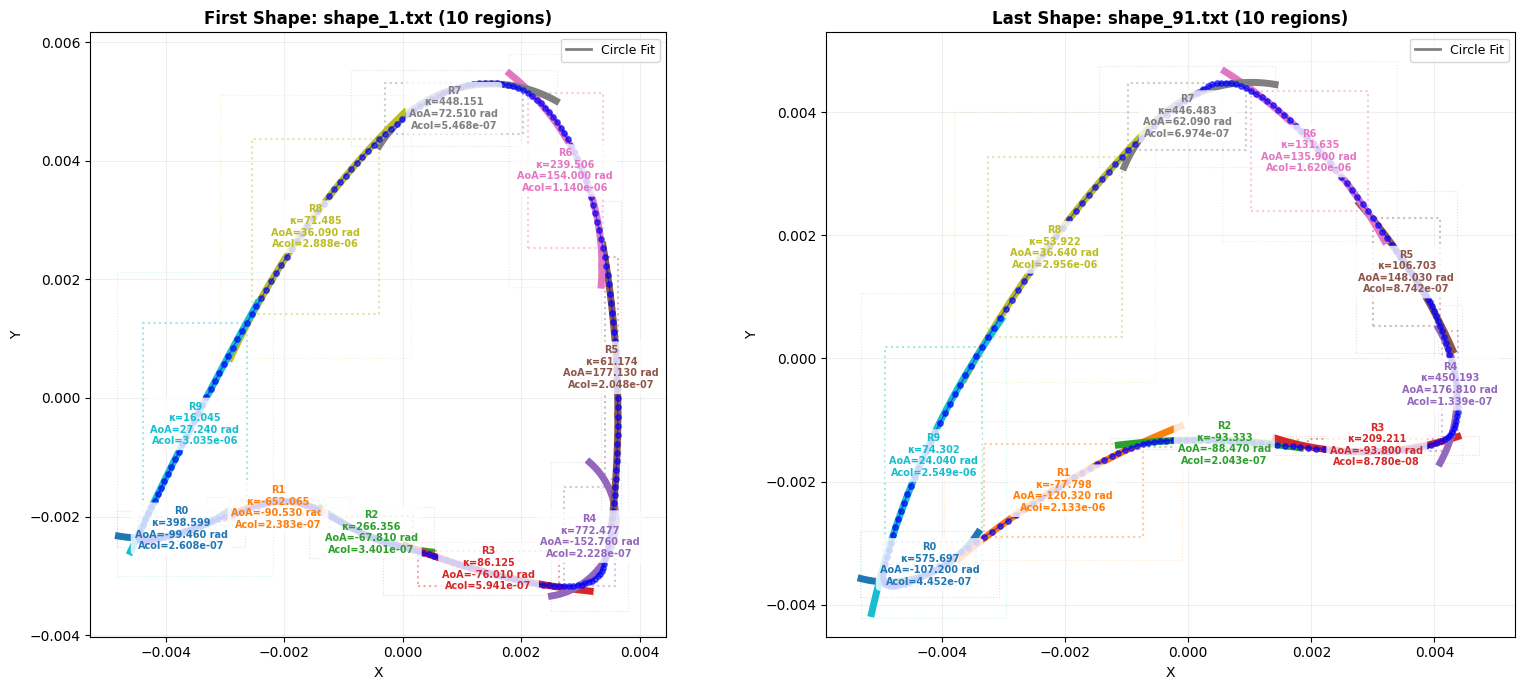


First shape: shape_1.txt
  Vertices: 253
  Regions: 10
    Region 0: 25 pts, Normal: (0.1644, -0.9864), Tangent: (-0.9864, -0.1644), Circle: center=(-0.0043810593971, 0.00014430773228), r=0.002509, κ=398.598545, AoA=-99.4600 rad
    Region 1: 25 pts, Normal: (0.0093, -1.0000), Tangent: (-1.0000, -0.0093), Circle: center=(-0.0020562742567, -0.0032775715291), r=-0.001534, κ=-652.064515, AoA=-90.5300 rad
    Region 2: 25 pts, Normal: (-0.3778, -0.9259), Tangent: (-0.9259, 0.3778), Circle: center=(0.00087259899723, 0.0011360898905), r=0.003754, κ=266.355855, AoA=-67.8100 rad
    Region 3: 25 pts, Normal: (-0.2417, -0.9704), Tangent: (-0.9704, 0.2417), Circle: center=(0.0043656611898, 0.0082885678114), r=0.011611, κ=86.125497, AoA=-76.0100 rad
    Region 4: 25 pts, Normal: (0.8891, -0.4577), Tangent: (-0.4577, -0.8891), Circle: center=(0.0023034040155, -0.002063051182), r=0.001295, κ=772.477221, AoA=-152.7600 rad
    Region 5: 25 pts, Normal: (0.9987, 0.0501), Tangent: (0.0501, -0.9987), C

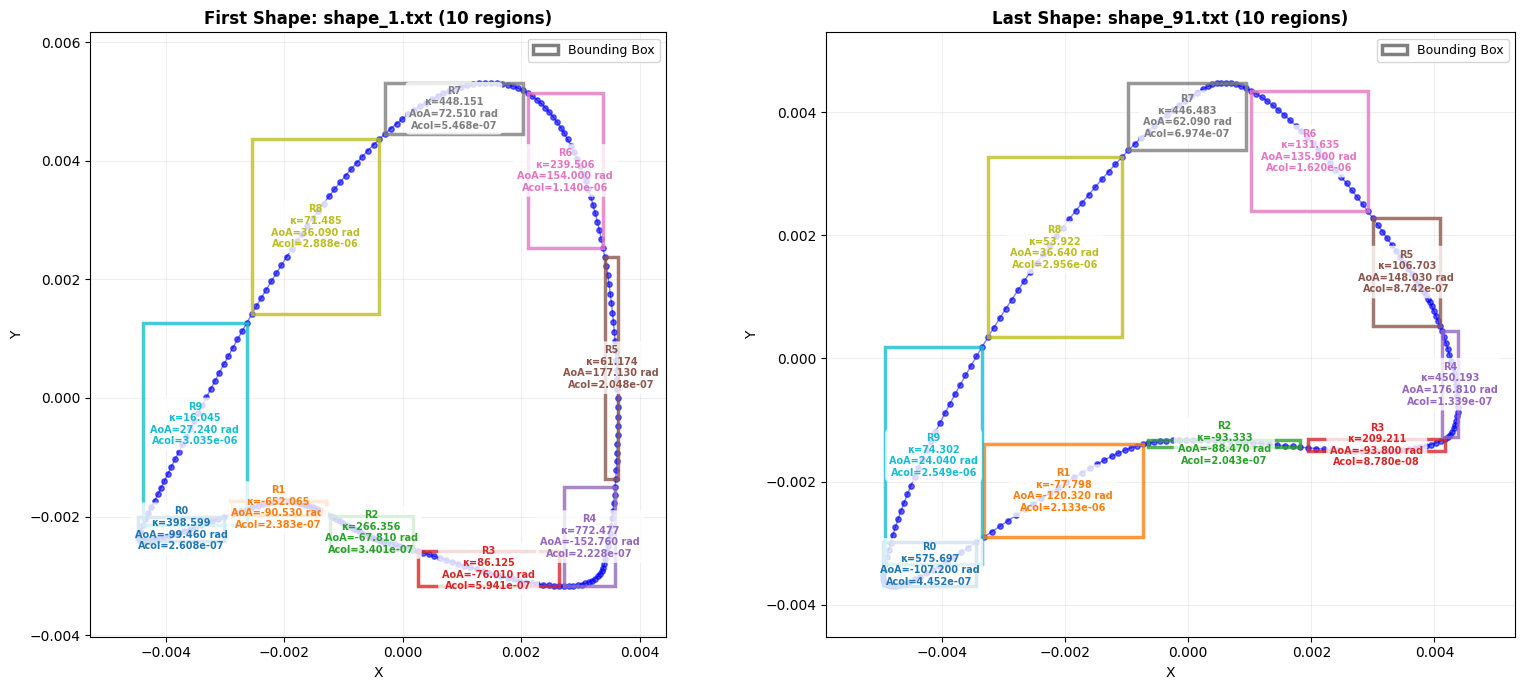


First shape: shape_1.txt
  Vertices: 253
  Regions: 10
    Region 0: 25 pts, Normal: (0.1644, -0.9864), Tangent: (-0.9864, -0.1644), Circle: center=(-0.0043810593971, 0.00014430773228), r=0.002509, κ=398.598545, AoA=-99.4600 rad
    Region 1: 25 pts, Normal: (0.0093, -1.0000), Tangent: (-1.0000, -0.0093), Circle: center=(-0.0020562742567, -0.0032775715291), r=-0.001534, κ=-652.064515, AoA=-90.5300 rad
    Region 2: 25 pts, Normal: (-0.3778, -0.9259), Tangent: (-0.9259, 0.3778), Circle: center=(0.00087259899723, 0.0011360898905), r=0.003754, κ=266.355855, AoA=-67.8100 rad
    Region 3: 25 pts, Normal: (-0.2417, -0.9704), Tangent: (-0.9704, 0.2417), Circle: center=(0.0043656611898, 0.0082885678114), r=0.011611, κ=86.125497, AoA=-76.0100 rad
    Region 4: 25 pts, Normal: (0.8891, -0.4577), Tangent: (-0.4577, -0.8891), Circle: center=(0.0023034040155, -0.002063051182), r=0.001295, κ=772.477221, AoA=-152.7600 rad
    Region 5: 25 pts, Normal: (0.9987, 0.0501), Tangent: (0.0501, -0.9987), C

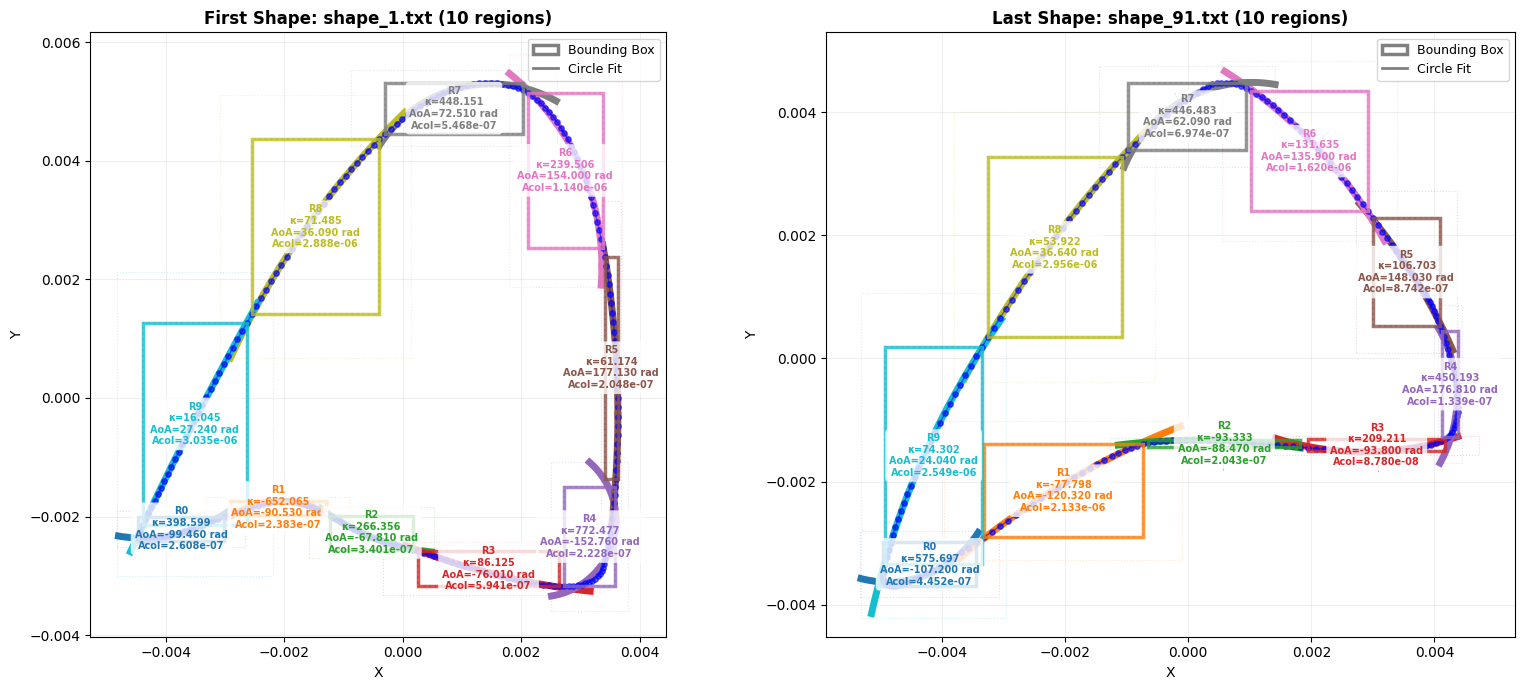


First shape: shape_1.txt
  Vertices: 253
  Regions: 10
    Region 0: 25 pts, Normal: (0.1644, -0.9864), Tangent: (-0.9864, -0.1644), Circle: center=(-0.0043810593971, 0.00014430773228), r=0.002509, κ=398.598545, AoA=-99.4600 rad
    Region 1: 25 pts, Normal: (0.0093, -1.0000), Tangent: (-1.0000, -0.0093), Circle: center=(-0.0020562742567, -0.0032775715291), r=-0.001534, κ=-652.064515, AoA=-90.5300 rad
    Region 2: 25 pts, Normal: (-0.3778, -0.9259), Tangent: (-0.9259, 0.3778), Circle: center=(0.00087259899723, 0.0011360898905), r=0.003754, κ=266.355855, AoA=-67.8100 rad
    Region 3: 25 pts, Normal: (-0.2417, -0.9704), Tangent: (-0.9704, 0.2417), Circle: center=(0.0043656611898, 0.0082885678114), r=0.011611, κ=86.125497, AoA=-76.0100 rad
    Region 4: 25 pts, Normal: (0.8891, -0.4577), Tangent: (-0.4577, -0.8891), Circle: center=(0.0023034040155, -0.002063051182), r=0.001295, κ=772.477221, AoA=-152.7600 rad
    Region 5: 25 pts, Normal: (0.9987, 0.0501), Tangent: (0.0501, -0.9987), C

In [6]:
# Demonstration of different visualization options for regions

print("\n" + "="*80)
print("CIRCLE FITTING VISUALIZATION DEMONSTRATION")
print("="*80)

sparta_folder = "shapes/dataset_2026-02-06_09_28_35/sparta_converted"
region_metadata_folder = os.path.join(sparta_folder, 'region_metadata')

print("\n--- Option 1: Show ONLY Fitted Circles (no bounding boxes) ---")
print("This is useful for examining circle fits in isolation")
plot_regions_comparison(sparta_folder, region_metadata_folder, 
                       show_bbox=False, show_circle=True, show_normal=False)

print("\n--- Option 2: Show ONLY Bounding Boxes (no circles) ---")
print("This is useful for examining bounding box coverage")
plot_regions_comparison(sparta_folder, region_metadata_folder, 
                       show_bbox=True, show_circle=False, show_normal=False)

print("\n--- Option 3: Show All (circles, boxes, and normals) ---")
print("This is the comprehensive view with all geometric data")
plot_regions_comparison(sparta_folder, region_metadata_folder, 
                       show_bbox=True, show_circle=True, show_normal=True)


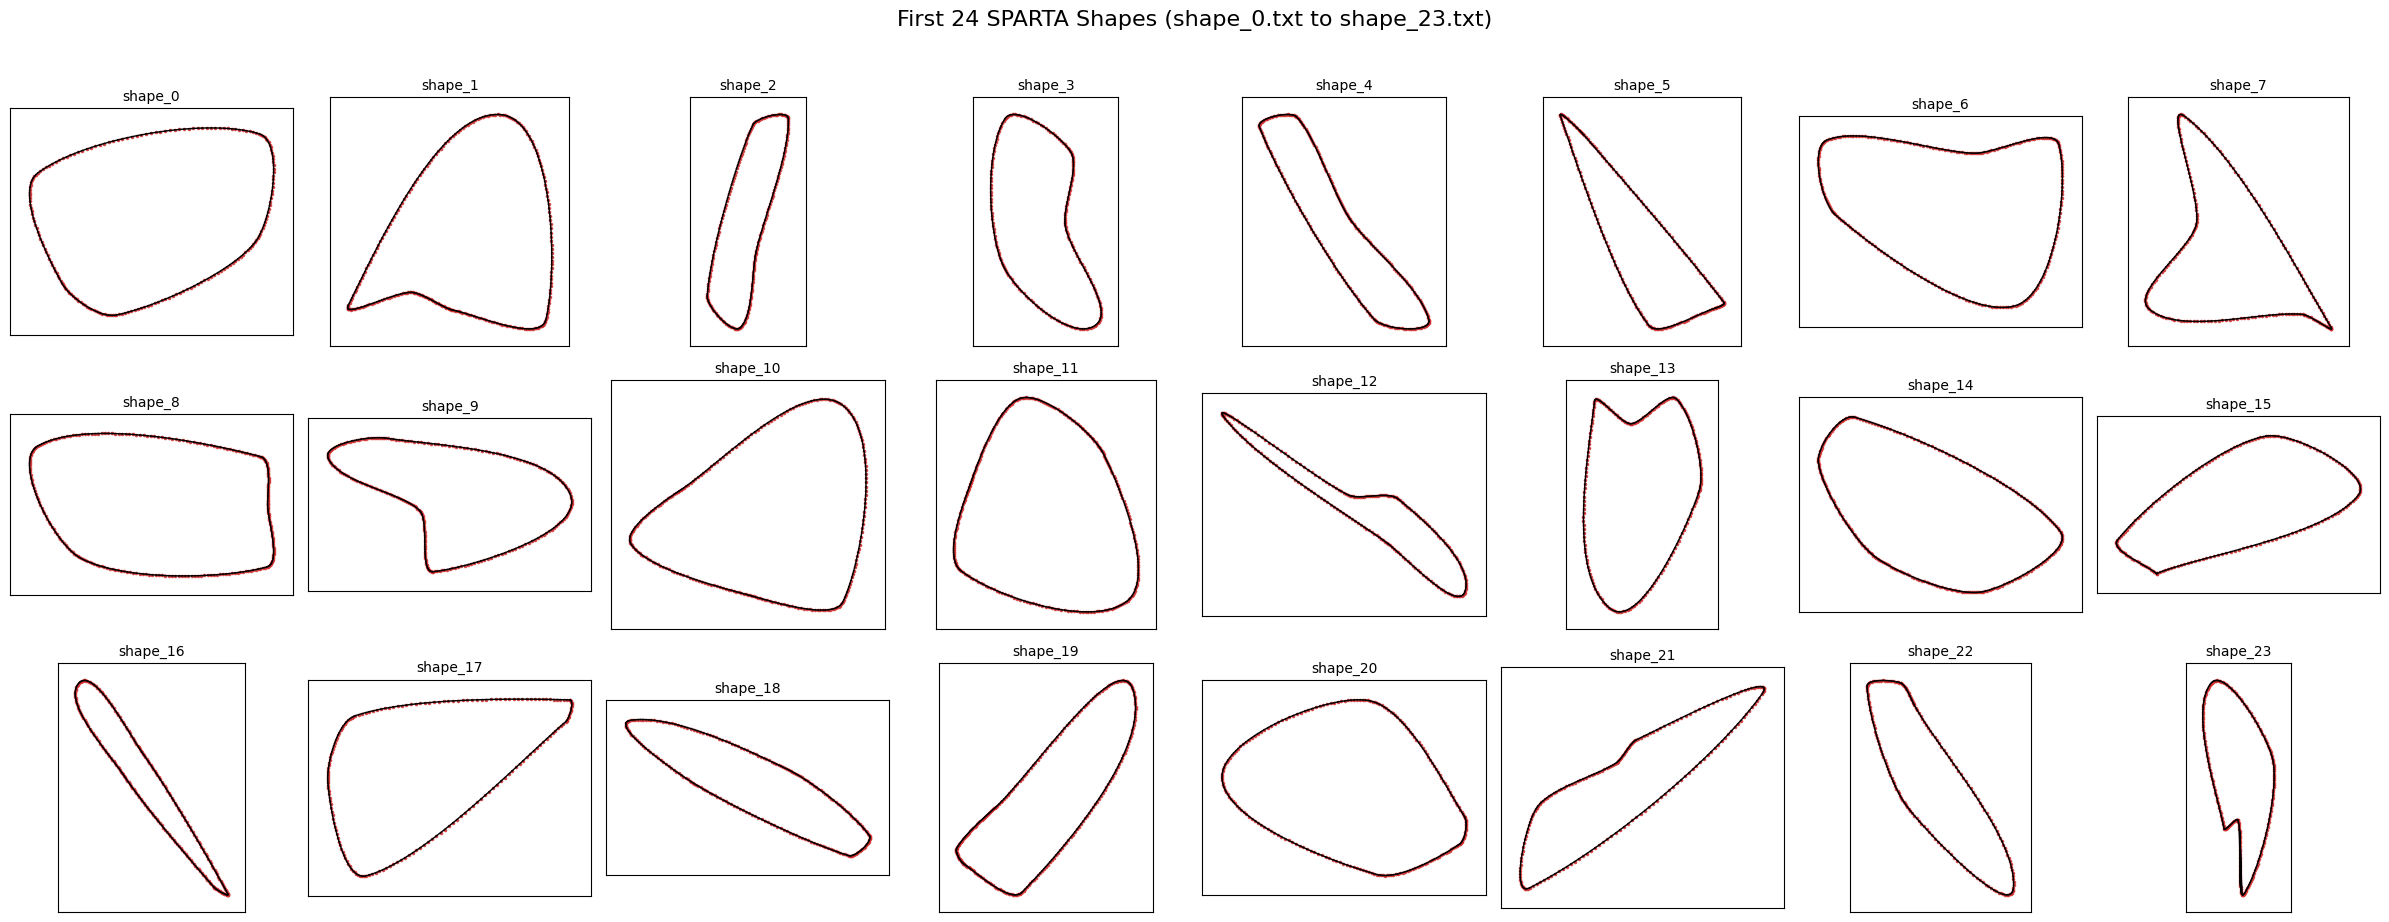

Saved image to: /Users/kofiblake/Documents/Meteor_Modelling/code/shapes/dataset_2026-02-06_09_28_35/first_24_shapes_grid.png
Done. Grid figure saved at: shapes/dataset_2026-02-06_09_28_35/first_24_shapes_grid.png


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt


def _read_sparta_points_lines(filepath):
    """Read a SPARTA file and return points + line segments."""
    points = {}
    line_segments = []

    with open(filepath, "r") as f:
        raw_lines = [line.strip() for line in f.readlines()]

    in_points = False
    in_lines = False

    for line in raw_lines:
        if not line:
            continue

        if line == "Points":
            in_points = True
            in_lines = False
            continue
        if line == "Lines":
            in_points = False
            in_lines = True
            continue

        if in_points:
            parts = line.split()
            if len(parts) >= 3:
                idx = int(parts[0])
                points[idx] = (float(parts[1]), float(parts[2]))
        elif in_lines:
            parts = line.split()
            if len(parts) >= 3:
                p1 = int(parts[1])
                p2 = int(parts[2])
                if p1 in points and p2 in points:
                    line_segments.append((points[p1], points[p2]))

    return points, line_segments


def plot_first_24_shapes_grid(root_folder, save_name="first_24_shapes_grid.png", dpi=300):
    """
    Plot shape_0.txt through shape_23.txt from <root_folder>/sparta_converted
    into a 3x8 grid, then save the image.
    """
    sparta_folder = os.path.join(root_folder, "sparta_converted")
    if not os.path.isdir(sparta_folder):
        raise FileNotFoundError(
            f"Could not find 'sparta_converted' inside: {os.path.abspath(root_folder)}"
        )

    fig, axes = plt.subplots(3, 8, figsize=(24, 9))
    axes = axes.ravel()

    for i in range(24):
        ax = axes[i]
        file_name = f"shape_{i}.txt"
        file_path = os.path.join(sparta_folder, file_name)

        if not os.path.isfile(file_path):
            ax.text(0.5, 0.5, f"Missing\n{file_name}", ha="center", va="center", fontsize=10)
            ax.set_title(f"shape_{i}", fontsize=10)
            ax.set_aspect("equal", adjustable="box")
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        if "read_sparta_file" in globals():
            points, line_segments = read_sparta_file(file_path)
        else:
            points, line_segments = _read_sparta_points_lines(file_path)

        for p1, p2 in line_segments:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="black", linewidth=1.0)

        if points:
            verts = np.array(list(points.values()))
            ax.scatter(verts[:, 0], verts[:, 1], s=2.5, color="#d32f2f", alpha=0.8)

            x_min, x_max = np.min(verts[:, 0]), np.max(verts[:, 0])
            y_min, y_max = np.min(verts[:, 1]), np.max(verts[:, 1])
            span = max(x_max - x_min, y_max - y_min, 1e-12)
            pad = 0.08 * span
            ax.set_xlim(x_min - pad, x_max + pad)
            ax.set_ylim(y_min - pad, y_max + pad)

        ax.set_title(f"shape_{i}", fontsize=10)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle("First 24 SPARTA Shapes (shape_0.txt to shape_23.txt)", fontsize=16, y=1.02)
    plt.tight_layout()

    save_path = os.path.join(root_folder, save_name)
    fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved image to: {os.path.abspath(save_path)}")
    return save_path


# Input the parent folder that contains "sparta_converted"
root_folder = input("Enter folder path (contains 'sparta_converted'): ").strip()
if not root_folder:
    root_folder = "."

saved_path = plot_first_24_shapes_grid(root_folder)
print(f"Done. Grid figure saved at: {saved_path}")